# Beryllene SOC topology results

Results of the current SOC topology campaign in `9.0_topology/`. All invariants are **conditional screening results** (`topology_certified: false`): each Z₂ value belongs to a fixed lowest-N spinor-band subspace and assumes electronic time reversal and isolation of that subspace. Except for 2H-α, the structures are metallic at neutral filling, so no value is a Fermi-level quantum-spin-Hall invariant.

[Calculation workflow and troubleshooting](9.0_topology/workflow.md) · [Report 2026-09-26](9.0_topology/topo_report_20260926.md) · analysis code: `vmatplot/band_topology.py`

In [1]:
# prework

from vmatplot.band_topology import summarize_topology, summarize_parity, summarize_gaps, summarize_gap_zoom
from vmatplot.band_topology import summarize_wcc, summarize_time_reversal
from vmatplot.band_topology import plot_topology_bands, plot_direct_gap_maps, plot_wcc, plot_gap_zoom
import matplotlib.pyplot as plt

topology_dir = "9.0_topology"
structures = [["α-beryllene", "9.0_topology/a-Beryllene"],
              ["β-beryllene", "9.0_topology/b-Beryllene"],
              ["ST-beryllene", "9.0_topology/c-Beryllene_trilayer"],
              ["2H-α-beryllene", "9.0_topology/a-Beryllene_hh"],
              ["1H-β-beryllene", "9.0_topology/b-Beryllene_b", "Blue", "Orange"],
              ["2H-β-beryllene", "9.0_topology/b-Beryllene_bb"]]

## Summary

In [2]:
summarize_topology(topology_dir);

| Structure | Directory | NELECT | Conditional invariant | Min. direct gap E(N+1)−E(N) | Neutral E_F | max \|m(r)\| (μB/Å³) | Spin seeds |
|---|---|---|---|---|---|---|---|
| α | a-Beryllene | 2 | ν = 1 (parity) | 1.13 meV | metal | 5.9e-08 | collapsed |
| β | b-Beryllene | 4 | ν = 0 (parity) | 0.854 meV | metal | 8.9e-08 | collapsed |
| ST | c-Beryllene_trilayer | 6 | ν = 1 (parity) | 0.735 meV | metal | 1.0e-07 | collapsed |
| 2H-α | a-Beryllene_hh | 4 | ν = 0 (parity) | 4.92 eV | insulator | 5.9e-08 | collapsed |
| 1H-β | b-Beryllene_b | 5 | N=4: Z₂ = 0 (WCC), N=6: Z₂ = 0 (WCC) | 0.929 eV, 0.415 eV | metal | 6.1e-08 | collapsed |
| 2H-β | b-Beryllene_bb | 6 | ν = 0 (parity) | 0.177 eV | metal | 2.6e-07 | collapsed |

## Fu–Kane parity at the four 2D TRIM

Kramers-pair parities from IrRep 2.1.3 at Γ, X = (½, 0), Y = (0, ½), M = (½, ½); after `|` the next pair above band N and E(N+1) − E(N) at that TRIM. The second table is the independent float64 check of the inversion matrix rebuilt from the WAVECAR (tolerances 1e-6; residual 1e-5).

In [3]:
summarize_parity(topology_dir);
summarize_parity(topology_dir, validation=True);

| Structure | N | Γ | X | Y | M | δ (Γ X Y M) | ν |
|---|---|---|---|---|---|---|---|
| α | 2 | + \| − (5.1 eV) | − \| + (6.37 eV) | − \| + (6.37 eV) | − \| + (6.37 eV) | + − − − | 1 |
| β | 4 | + − \| + (2.81 eV) | + − \| − (5.24 eV) | + − \| − (5.95 eV) | + − \| − (5.52 eV) | − − − − | 0 |
| ST | 6 | + − + \| − (2.22 eV) | + − + \| − (5.1 eV) | + − + \| − (5.1 eV) | − − + \| + (1.28 meV) | − − − + | 1 |
| 2H-α | 4 | + − \| + (9.79 eV) | − + \| − (5.64 eV) | − + \| − (5.64 eV) | − + \| − (5.64 eV) | − − − − | 0 |
| 2H-β | 6 | + − + \| − (8.37 eV) | − + + \| − (1.3 eV) | + − − \| + (1.3 eV) | − + − \| + (0.177 eV) | − − + + | 0 |

| Structure | Löwdin unitarity error | Opposite-parity overlap | Inversion residual | Same-parity overlap (PAW metric) | IrRep plain-metric message |
|---|---|---|---|---|---|
| α | 2.6e-12 | 1.0e-08 | 2.2e-06 | 3.5e-08 | none |
| β | 1.5e-11 | 4.0e-08 | 5.0e-06 | 2.6e-02 | 1.1e-05, 1.2e-05 |
| ST | 1.0e-11 | 2.2e-08 | 3.7e-06 | 8.5e-03 | 0.00653, 1.84e-05, 1.82e-05, 1.26e-05 |
| 2H-α | 1.6e-11 | 2.2e-08 | 5.7e-06 | 1.7e-02 | 3.62e-05, 3.73e-05, 3.77e-05, 4.43e-05 |
| 2H-β | 2.5e-11 | 2.3e-08 | 6.4e-06 | 2.0e-02 | 0.0155, 0.00798, 0.00791, 0.00286 |

## SOC bands and the lowest-N subspace

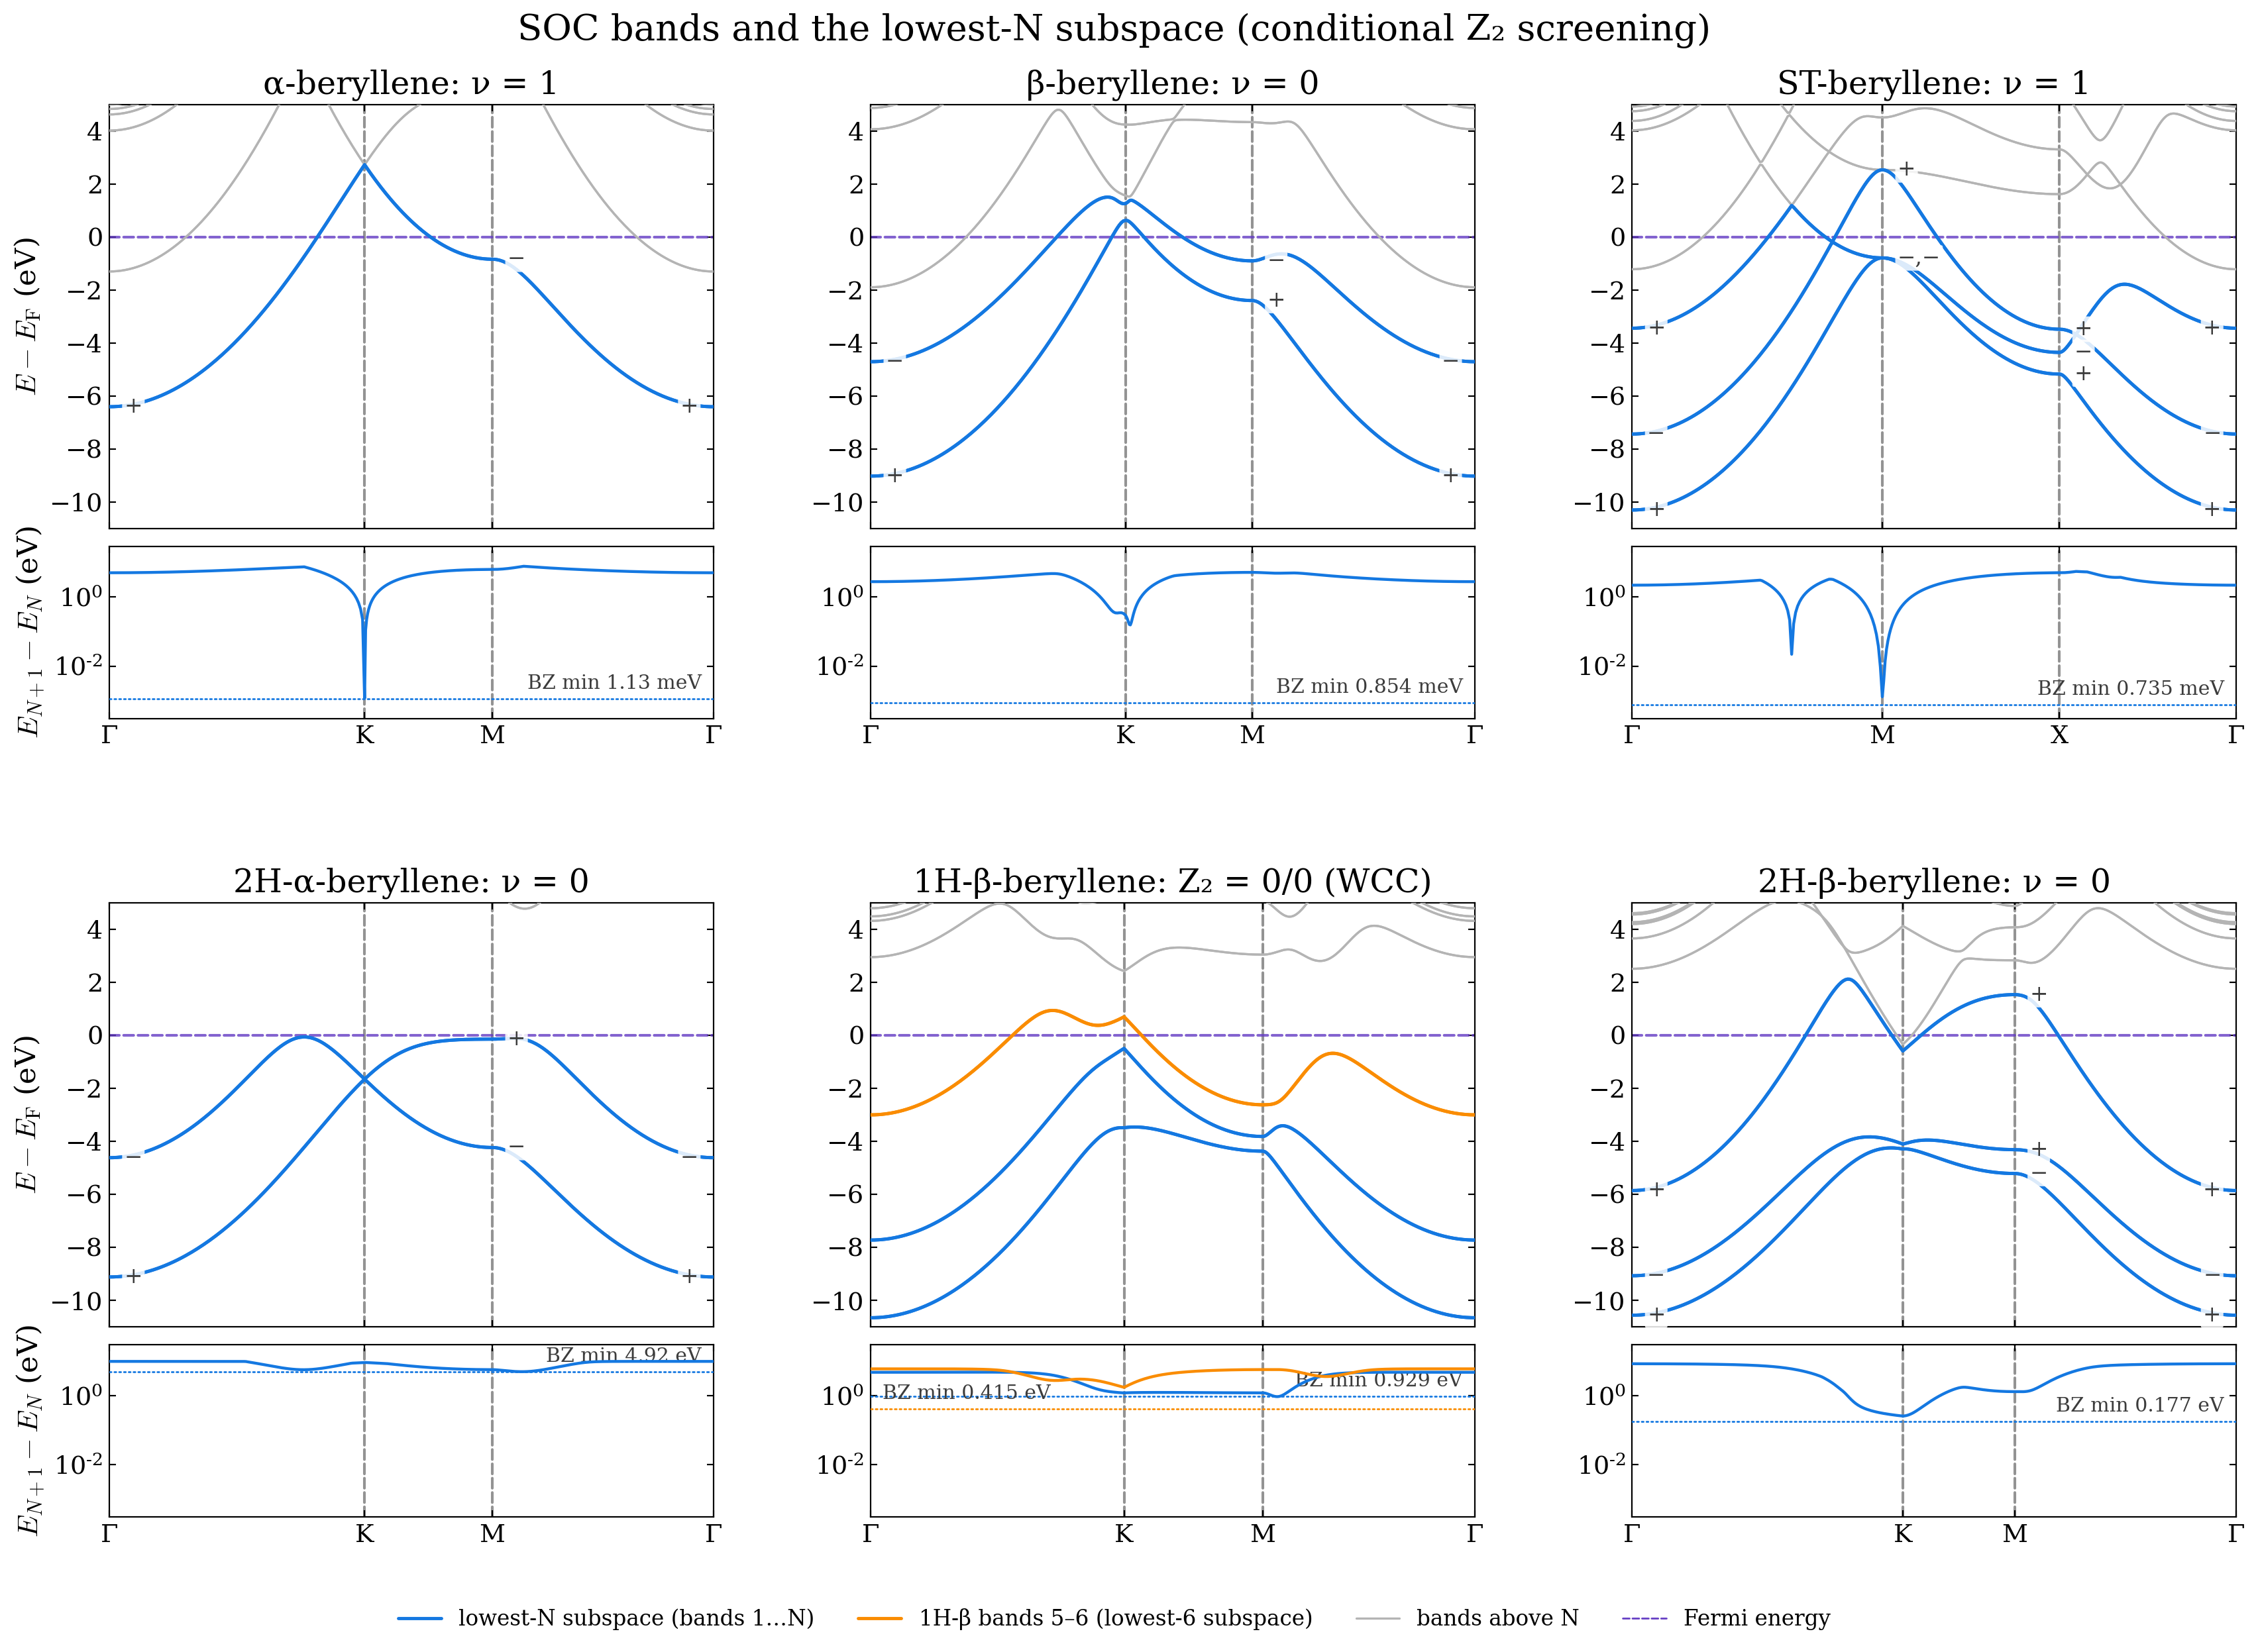

In [4]:
plot_topology_bands("SOC bands and the lowest-N subspace (conditional Z₂ screening)", structures, (-11, 5))
plt.savefig("figures/9_topology/9.1_topology_bands.pdf")

## Isolation of the subspace and the neutral Fermi level

Minimum sampled direct gap E(N+1) − E(N) over the SCF grid, the TRIM, the band path and all refinements; band extrema relative to the SCF Fermi level. A negative indirect gap means bands N and N+1 both cross E_F.

In [5]:
summarize_gaps(topology_dir);

| Structure | N | Min. direct gap | k (fractional) | Stage | max E_N − E_F (eV) | min E_N+1 − E_F (eV) | Indirect gap (eV) |
|---|---|---|---|---|---|---|---|
| α | 2 | 1.13 meV | (0.33333, 0.33333) | gap_refine_3d | +2.722 | -1.307 | -4.029 |
| β | 4 | 0.854 meV | (0.32842, 0.31373) | gap_refine_3e | +1.617 | -1.901 | -3.518 |
| ST | 6 | 0.735 meV | (0.31935, 0.31935) | gap_refine_3d | +2.528 | -1.222 | -3.750 |
| 2H-α | 4 | 4.92 eV | (0.43333, 0.00000) | gap_refine_1 | -0.065 | +4.776 | +4.842 |
| 1H-β | 4 | 0.929 eV | (0.46607, 0.00000) | gap_refine_2 | +0.083 | -3.004 | -3.087 |
| 1H-β | 6 | 0.415 eV | (0.21786, 0.37738) | gap_refine_2 | +3.334 | +2.311 | -1.023 |
| 2H-β | 6 | 0.177 eV | (-0.49524, 0.49524) | scf | +2.120 | -4.033 | -6.152 |

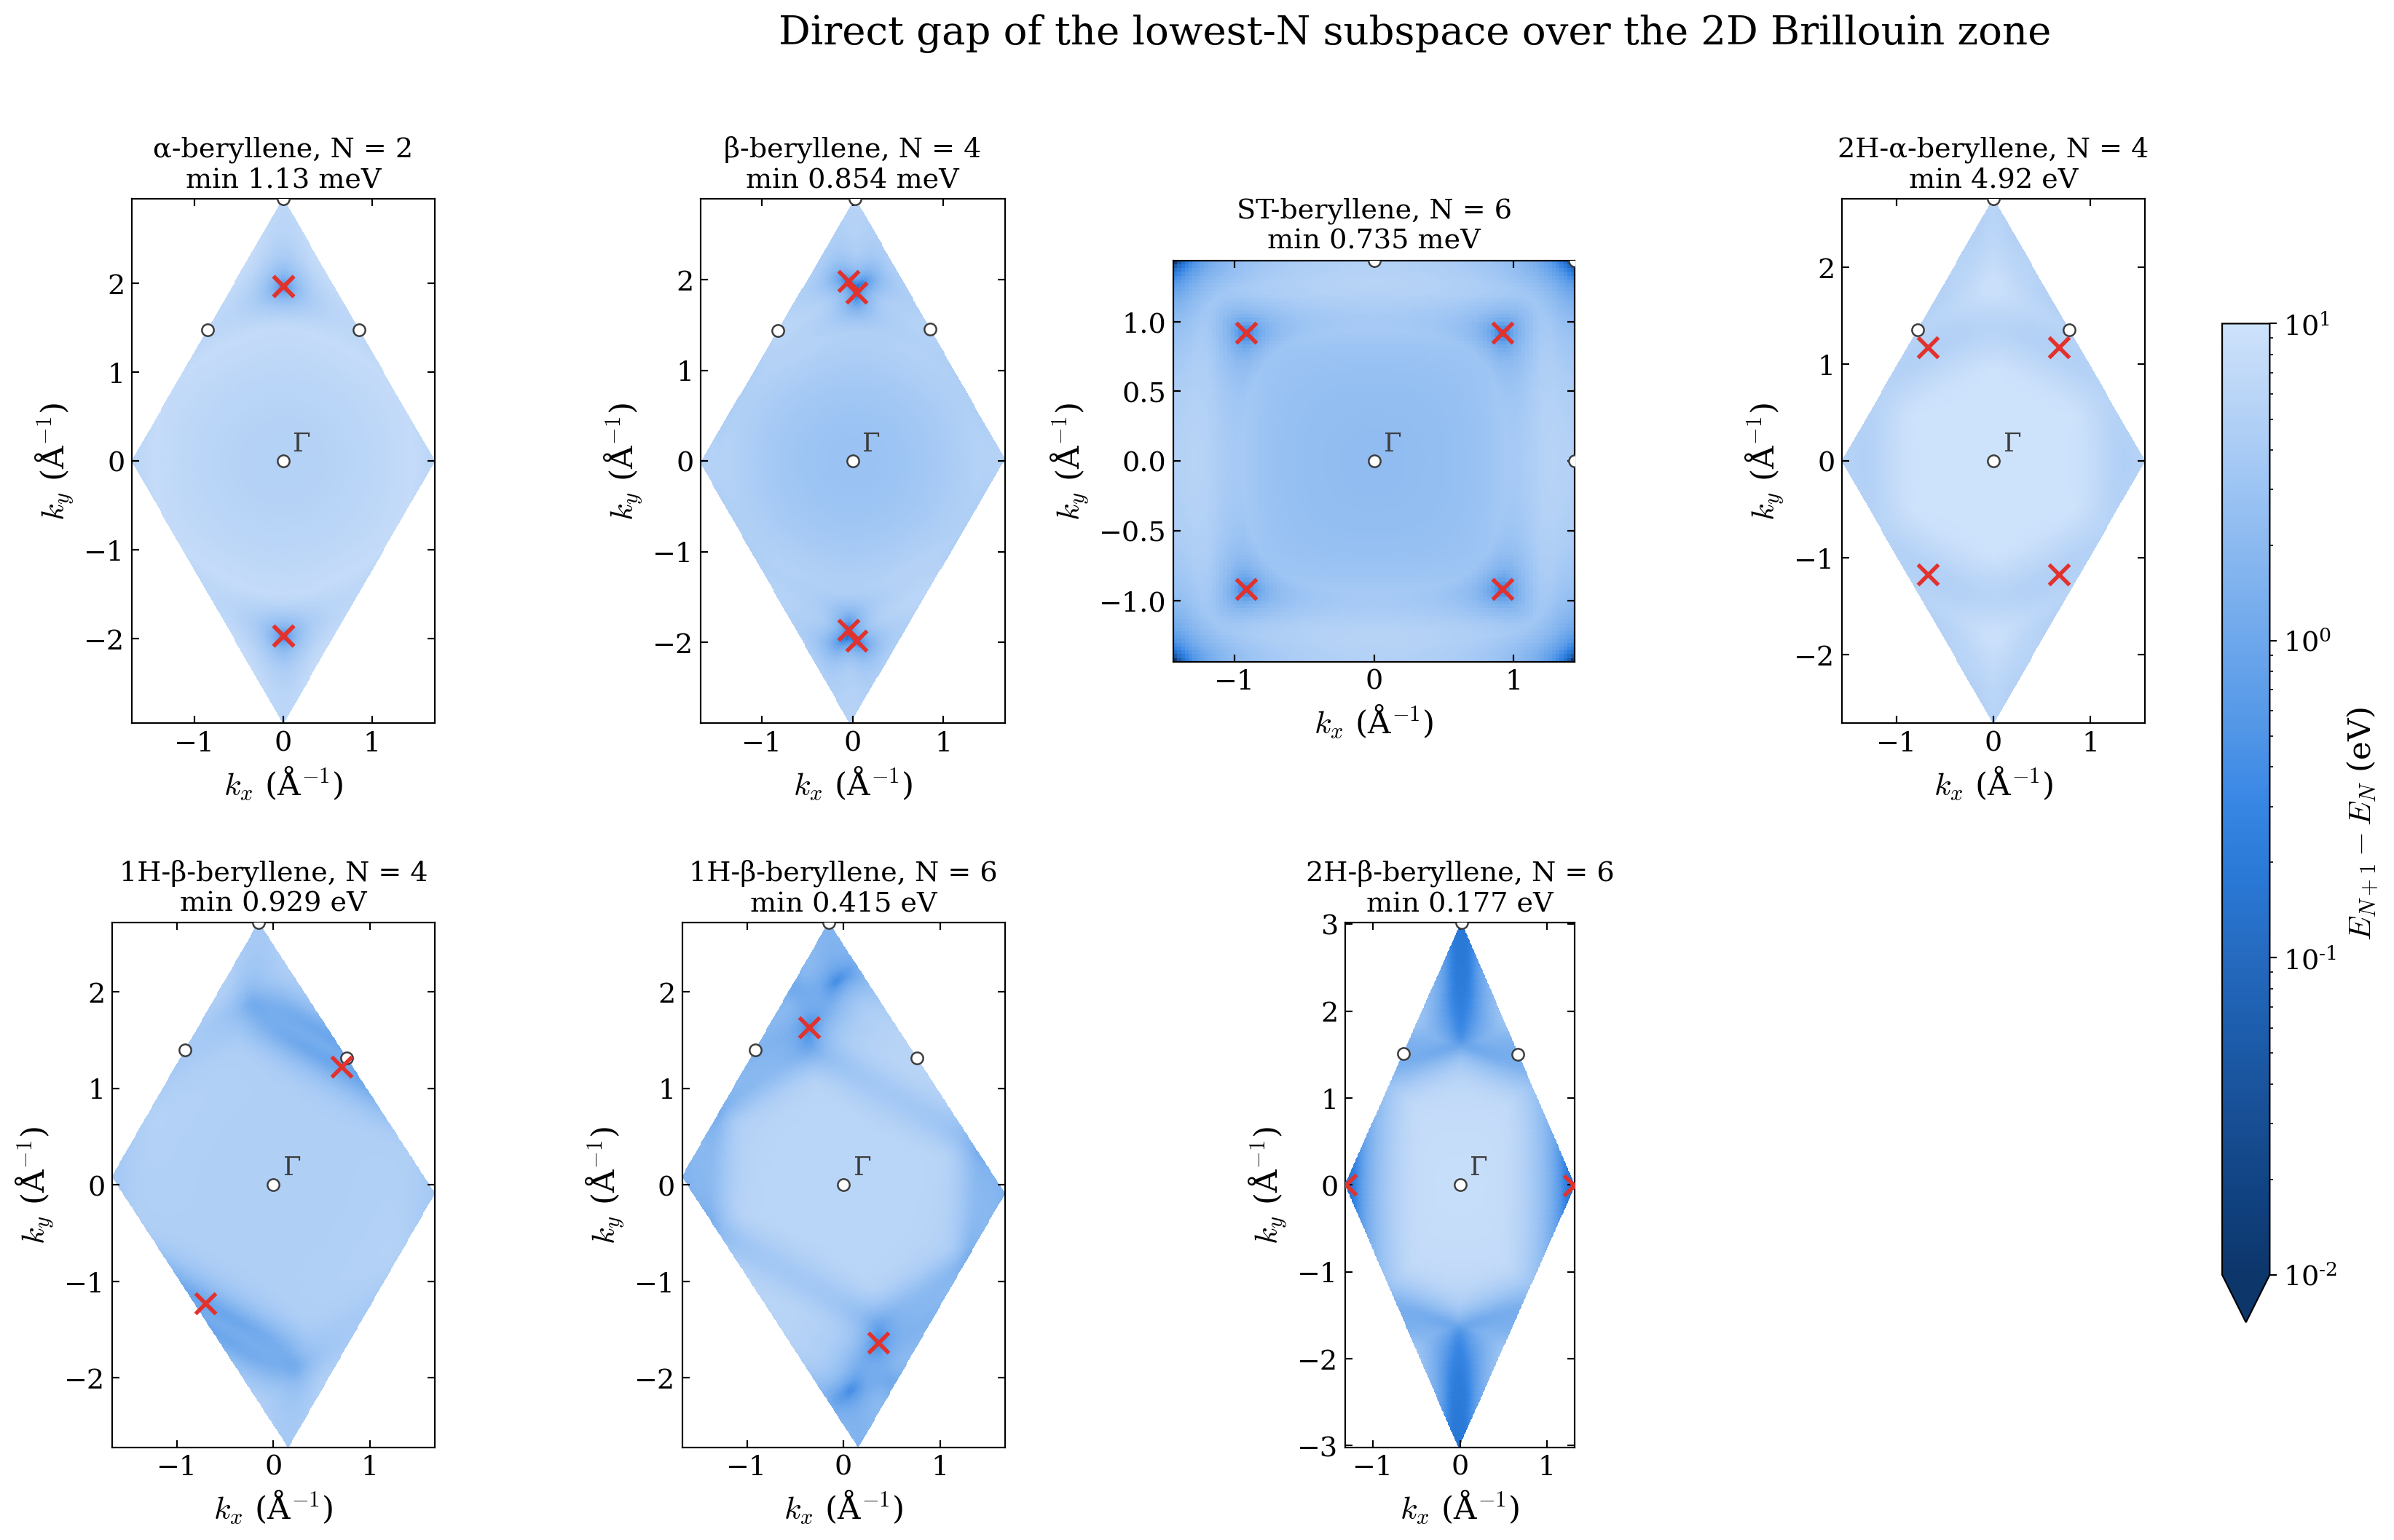

In [6]:
plot_direct_gap_maps("Direct gap of the lowest-N subspace over the 2D Brillouin zone", structures)
plt.savefig("figures/9_topology/9.2_direct_gap_maps.pdf", bbox_inches="tight")

### Adaptive zoom into the smallest direct gaps (`gap_refine_3*`)

9×9 patches re-centred on each basin minimum and shrunk 4× when the minimum is interior. The slope bound is min gap − (largest neighbour slope) × (sampling radius): positive values support, but do not prove, a gap.

In [7]:
summarize_gap_zoom(topology_dir);

| Structure | Basin (start k) | Levels | Min. gap per level (meV) | Final k | Final spacing | Interior | Slope bound (meV) |
|---|---|---|---|---|---|---|---|
| α | 1: (0.33333, 0.33333) | 4 | 1.156 → 1.156 → 1.156 → 1.127 | (0.3333287, 0.3333310) | 2.3e-06 | yes | +1.068 |
| β | 1: (0.32338, 0.36190) | 5 | 1.013 → 1.013 → 0.877 → 0.874 → 0.874 | (0.3233724, 0.3619238) | 5.8e-07 | yes | +0.869 |
| β | 2: (0.32830, 0.31350) | 5 | 6.087 → 4.327 → 1.171 → 0.882 → 0.854 | (0.3284209, 0.3137278) | 4.6e-06 | yes | +0.781 |
| ST | 1: (0.31936, 0.31936) | 5 | 0.865 → 0.865 → 0.865 → 0.735 → 0.735 | (0.3193507, 0.3193507) | 2.3e-06 | yes | +0.715 |

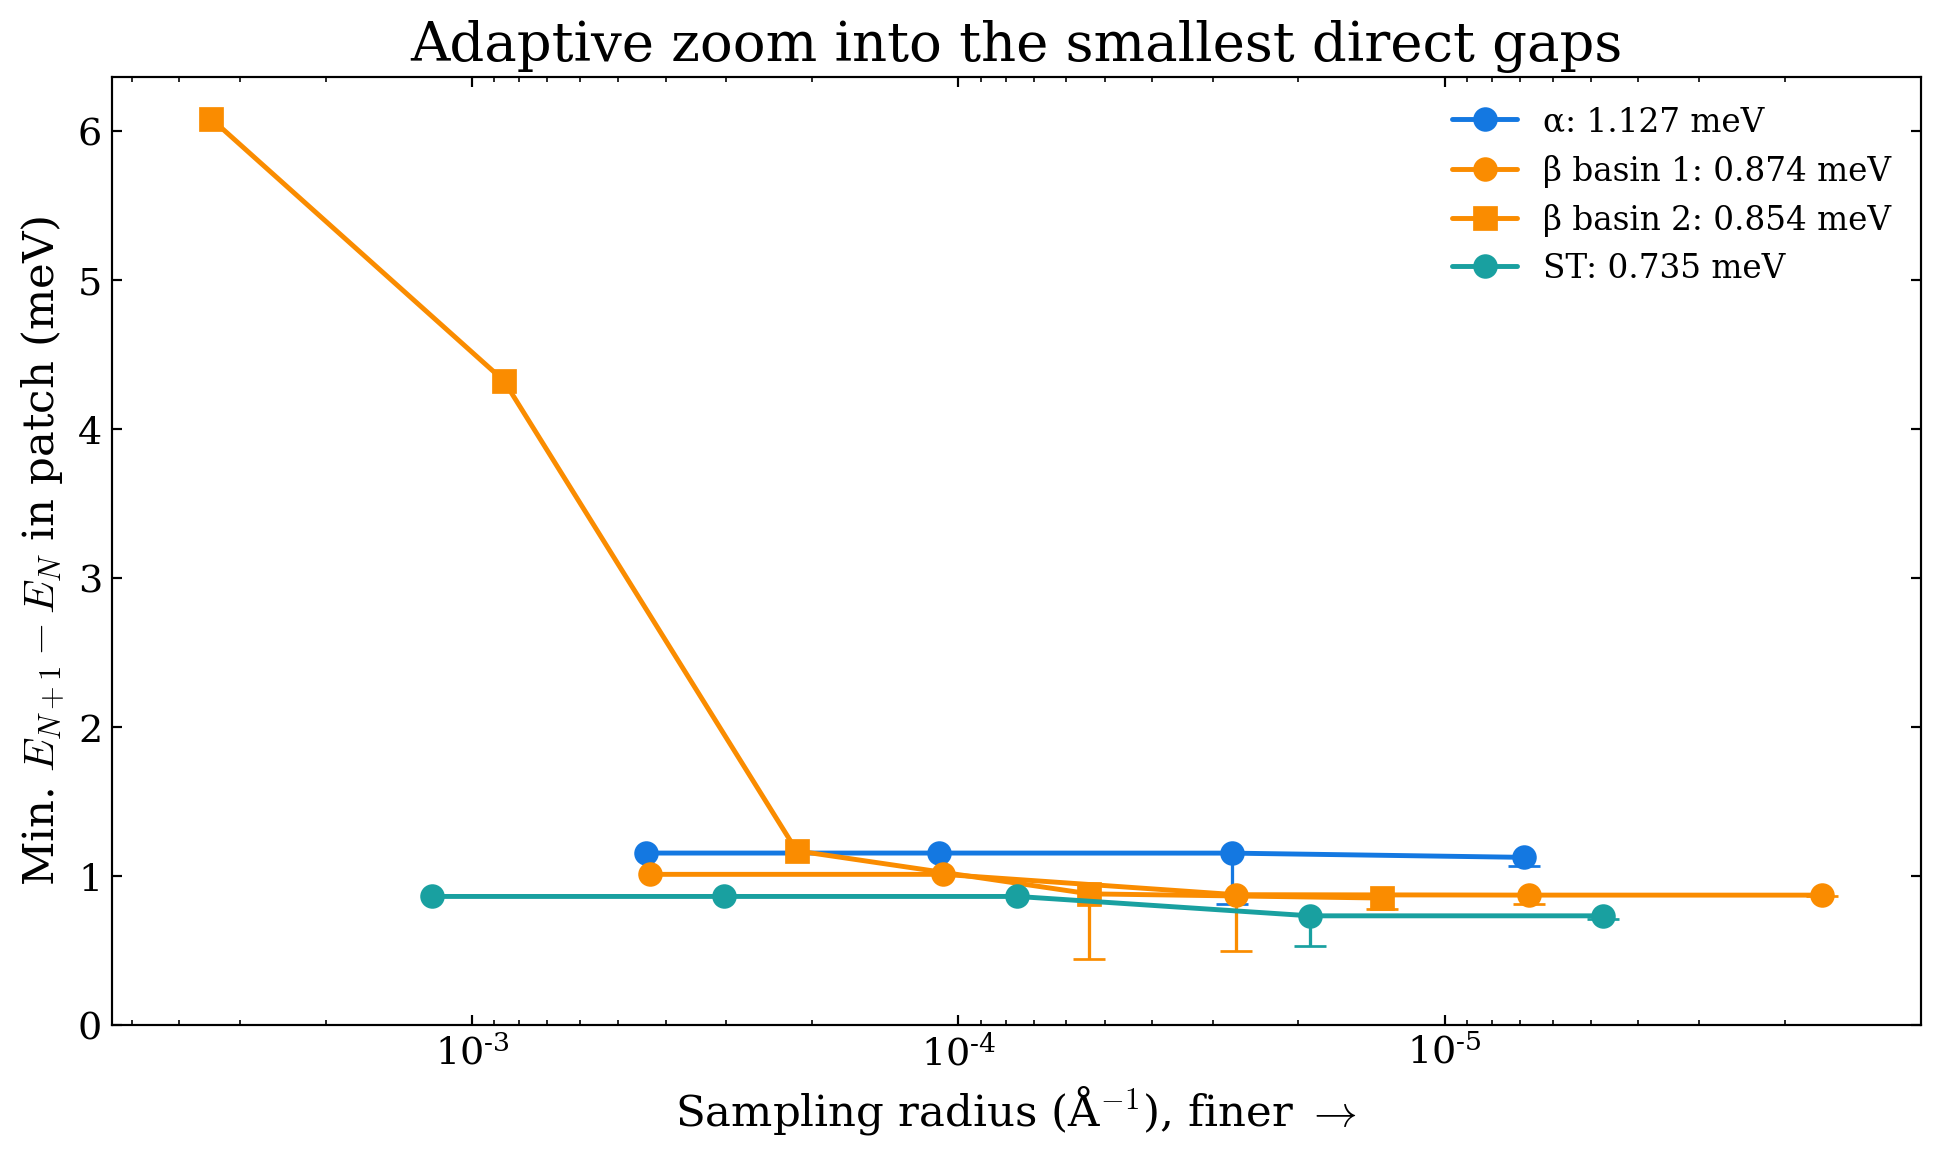

In [8]:
plot_gap_zoom("Adaptive zoom into the smallest direct gaps", [["α", "9.0_topology/a-Beryllene", "Blue"],
                                                              ["β", "9.0_topology/b-Beryllene", "Orange"],
                                                              ["ST", "9.0_topology/c-Beryllene_trilayer", "Cyan"]])
plt.savefig("figures/9_topology/9.3_gap_zoom.pdf")

## Wilson-loop WCC of 1H-β (no inversion)

Direct SOC-DFT overlaps (VASP–Wannier90) and Z2Pack on the surface [t, s/2, 0]. With five electrons the lowest-4 and lowest-6 subspaces are isolated sub-manifolds of a metal, not the occupied manifold.

In [9]:
summarize_wcc(topology_dir);

| Structure | Bands | Status | Conditional Z₂ | Min. sampled direct gap | Wilson loops | Certified |
|---|---|---|---|---|---|---|
| 1H-β | 4 | converged_sampled_subspace | 0 | 0.929 eV | 23 | False |
| 1H-β | 6 | converged_sampled_subspace | 0 | 0.415 eV | 23 | False |

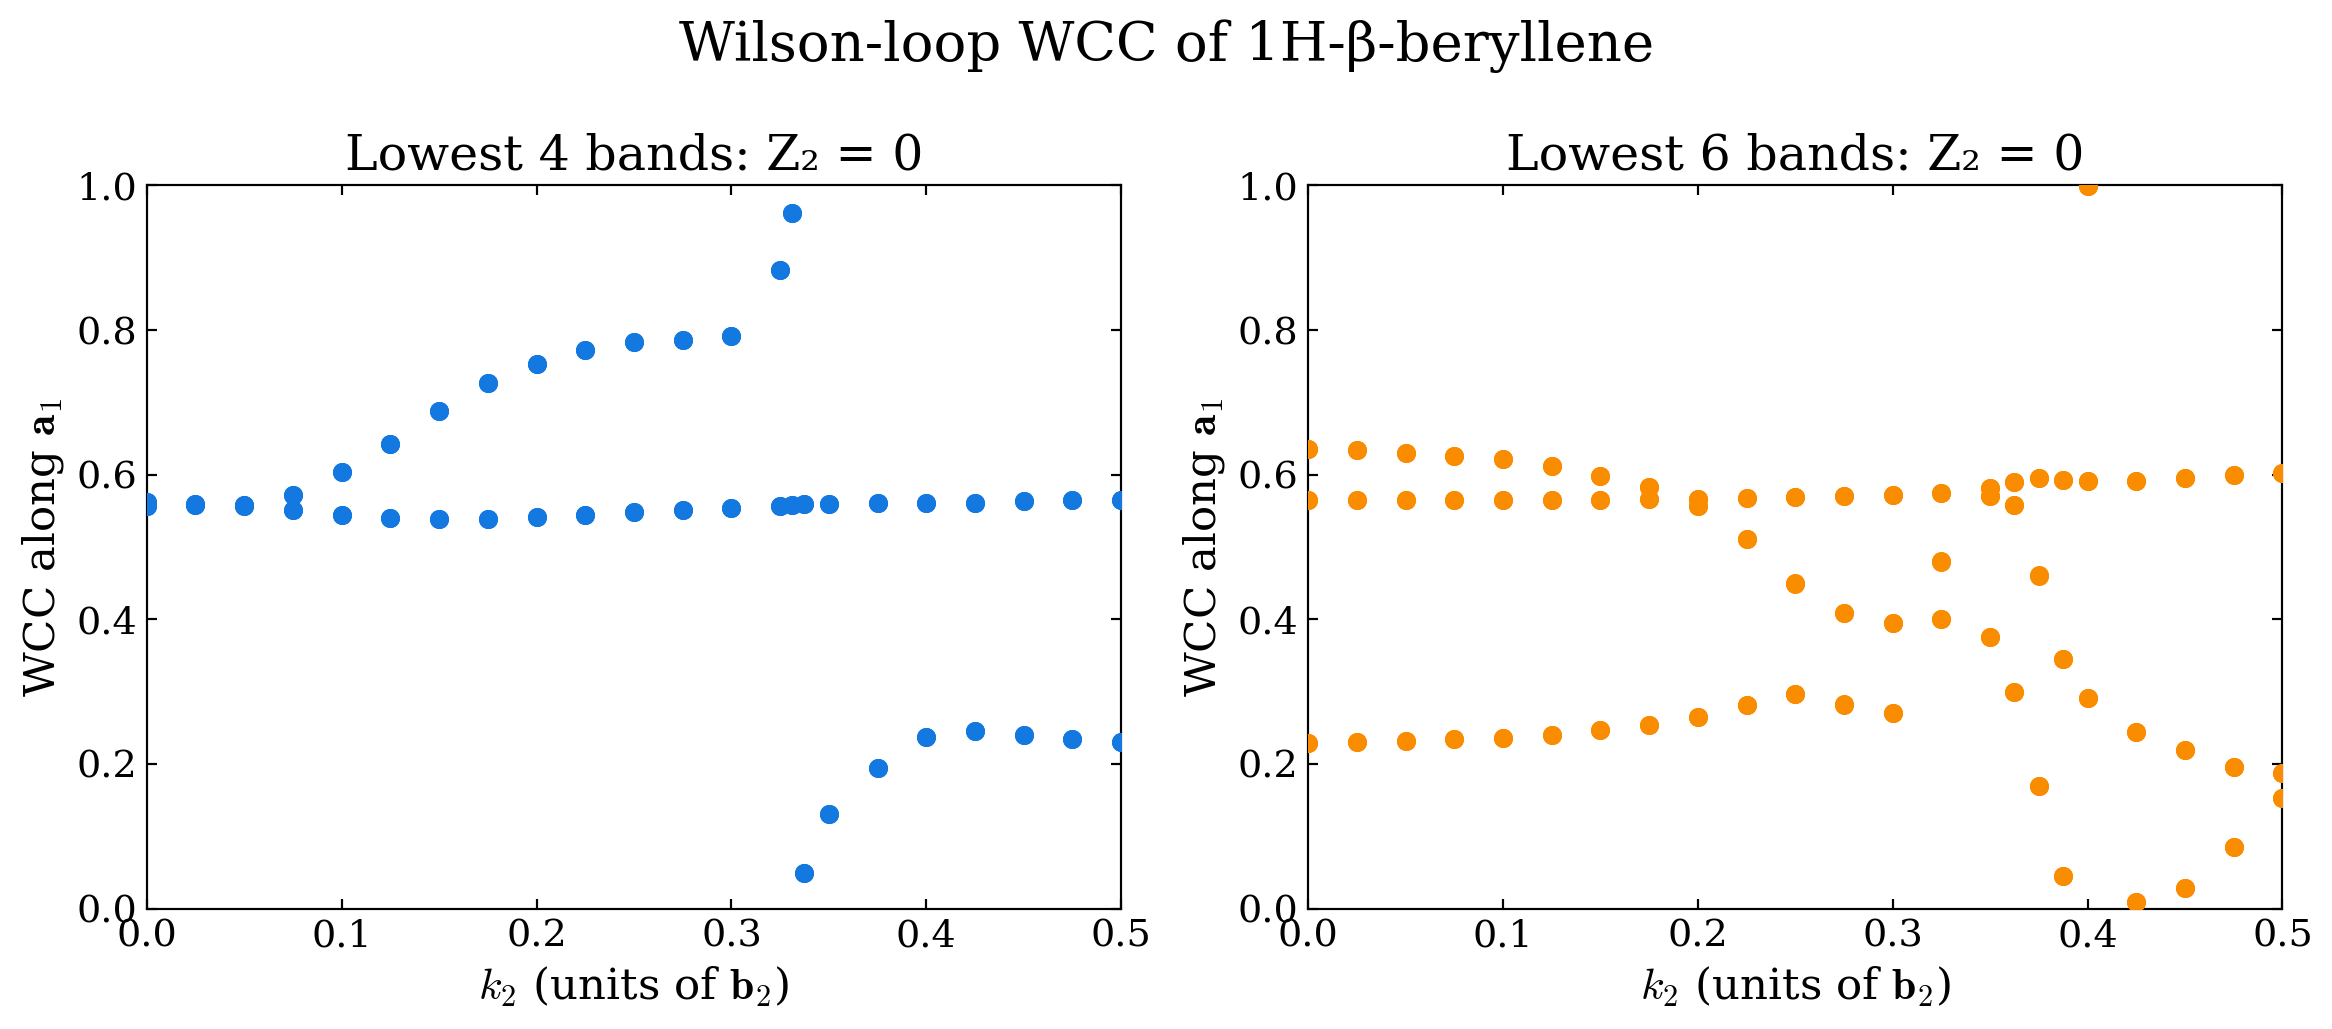

In [10]:
plot_wcc("Wilson-loop WCC of 1H-β-beryllene", [["1H-β-beryllene", "9.0_topology/b-Beryllene_b", "Blue", "Orange"]])
plt.savefig("figures/9_topology/9.4_wcc_beta_1h.pdf")

## Electronic time reversal

Converged SOC state: magnetisation density and one-centre PAW magnetisation from the SCF CHGCAR, Kramers splitting at the TRIM, and for 1H-β E(k) = E(−k) on the unsymmetrised SCF grid. Stability of the nonmagnetic state: collinear ISPIN = 2 SCFs from ferromagnetic, layer-alternating and inversion-odd seeds.

In [11]:
summarize_time_reversal(topology_dir);
summarize_time_reversal(topology_dir, spin_screen=True);

| Structure | max \|m(r)\| (μB/Å³) | ∫\|m\| (μB) | One-centre m: max \|Re\| / max \|Im\| | TRIM Kramers splitting (eV) | max \|E(k)−E(−k)\| (eV) |
|---|---|---|---|---|---|
| α | 5.9e-08 | 1.6e-07 | 2.3e-07 / 6.7e-05 | 1.5e-07 | — |
| β | 8.9e-08 | 6.9e-07 | 3.7e-08 / 7.3e-05 | 1.7e-07 | — |
| ST | 1.0e-07 | 5.3e-07 | 8.4e-08 / 8.4e-05 | 5.5e-09 | — |
| 2H-α | 5.9e-08 | 2.0e-07 | 6.1e-08 / 7.6e-05 | 1.8e-06 | — |
| 1H-β | 6.1e-08 | 1.6e-07 | 7.9e-08 / 8.4e-05 | 1.2e-06 | 4.0e-07 (5512 pairs) |
| 2H-β | 2.6e-07 | 8.9e-07 | 3.0e-07 / 9.0e-05 | 3.8e-06 | — |

| Structure | Seed | Initial moments (μB) | Final total (μB) | Final max \|site\| (μB) | Collapsed |
|---|---|---|---|---|---|
| α | fm | 1 | 0.0000 | 0.0000 | yes |
| β | fm | 1 1 | 0.0000 | 0.0000 | yes |
| β | afm | -1 1 | -0.0000 | 0.0000 | yes |
| ST | fm | 1 1 1 | 0.0000 | 0.0000 | yes |
| ST | afm | 1 -1 1 | -0.0000 | 0.0000 | yes |
| ST | p_odd | -1 0 1 | 0.0000 | 0.0000 | yes |
| 2H-α | fm | 1 0.5 0.5 | 0.0000 | 0.0000 | yes |
| 1H-β | fm | 1 1 0.5 | -0.0000 | 0.0000 | yes |
| 1H-β | afm | -1 1 0 | 0.0000 | 0.0000 | yes |
| 2H-β | fm | 1 1 0.5 0.5 | -0.0000 | 0.0000 | yes |
| 2H-β | afm | -1 1 0 0 | 0.0000 | 0.0000 | yes |